## **Visión por Computadora I — TP2**
**Integrantes:**

Carmen Rodríguez

Matías Bovio

Gonzalo Rodríguez


# TP2 - Detector de máximo enfoque en video

En este trabajo se analiza cómo cambia el enfoque a lo largo de un video utilizando la métrica **FM** propuesta en el paper trabajado en clase.

La idea es:

1. implementar la métrica FM;
2. probarla primero sobre un frame;
3. medir el video completo frame a frame;
4. detectar una **región continua de máximo enfoque** usando el 90% del valor máximo;
5. repetir el análisis sobre una **ROI central proporcional al 10% del área**;
6. verificar visualmente los resultados;
7. aplicar **Unsharp Masking** cerca de los límites de la región enfocada;
8. comparar el video original con el procesado.

Los resultados y conclusiones finales se generan a partir de las variables obtenidas en la ejecución, para que sean consistentes con las salidas reales del notebook.


## 1. Librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 2. Carga del video

Antes de ejecutar esta celda en Google Colab, subir el archivo `focus_video.mov` al entorno.


In [2]:
video_path = 'focus_video.mov'

captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    raise FileNotFoundError(
        "No se pudo abrir focus_video.mov. "
        "Verificar que el archivo esté cargado en el entorno."
    )

total_frames = int(captura_video.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(captura_video.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(captura_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = captura_video.get(cv2.CAP_PROP_FPS)
duracion = total_frames / fps if fps > 0 else 0

captura_video.release()

print('Frames:', total_frames)
print('Resolución:', frame_width, 'x', frame_height)
print('FPS:', round(fps, 2))
print('Duración aproximada:', round(duracion, 2), 'segundos')


Frames: 171
Resolución: 640 x 360
FPS: 29.97
Duración aproximada: 5.71 segundos


## 3. Métrica FM

La métrica sigue los pasos del paper:

1. calcular la Transformada de Fourier 2D;
2. desplazar el origen al centro;
3. obtener el módulo del espectro;
4. buscar el valor máximo;
5. definir el umbral `M / 1000` y contar cuántos valores lo superan;
6. normalizar esa cantidad por el número total de píxeles.

Un frame con mayor presencia relativa de componentes relevantes de alta frecuencia obtiene un valor FM mayor.


In [3]:
def medir_enfoque_fm(imagen_gris):
    # 1. Transformada de Fourier 2D
    F = np.fft.fft2(imagen_gris)

    # 2. Centrar el espectro
    Fc = np.fft.fftshift(F)

    # 3. Módulo
    AF = np.abs(Fc)

    # 4. Máximo
    M = np.max(AF)

    # 5. Umbral y cantidad de componentes que lo superan
    threshold = M / 1000
    TH = np.sum(AF > threshold)

    # 6. Normalización por cantidad de píxeles
    alto, ancho = imagen_gris.shape
    FM = TH / (alto * ancho)

    return FM


## 4. Prueba inicial sobre un frame

Antes de recorrer todo el video, se verificó que la función pueda aplicarse correctamente a un frame individual.


FM del frame de prueba: 0.007122395833333333


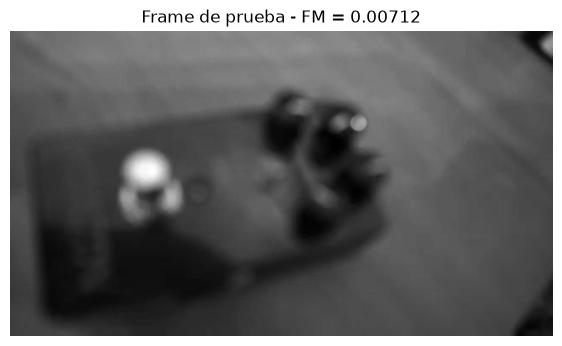

In [4]:
captura_video = cv2.VideoCapture(video_path)
ret, frame_prueba_color = captura_video.read()
captura_video.release()

if not ret:
    raise RuntimeError('No se pudo leer el primer frame del video.')

frame_prueba_gris = cv2.cvtColor(frame_prueba_color, cv2.COLOR_BGR2GRAY)
fm_prueba = medir_enfoque_fm(frame_prueba_gris)

print('FM del frame de prueba:', fm_prueba)

plt.figure(figsize=(7, 4))
plt.imshow(frame_prueba_gris, cmap='gray')
plt.title('Frame de prueba - FM = ' + str(round(fm_prueba, 5)))
plt.axis('off')
plt.show()


## 5. Experimento 1: frame completo

Ahora se ejecuta el video completo, se convierte cada frame a escala de grises y se calcula FM sobre toda la imagen.


In [5]:
captura_video = cv2.VideoCapture(video_path)

fm_frame_completo = []
frames_grises = []

while True:
    ret, frame = captura_video.read()

    if not ret:
        break

    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frames_grises.append(frame_gris)
    fm_frame_completo.append(medir_enfoque_fm(frame_gris))

captura_video.release()

fm_frame_completo = np.array(fm_frame_completo)

print('Frames procesados:', len(fm_frame_completo))


Frames procesados: 171


### 5.1 Segmento continuo de máximo enfoque

Se usa como referencia el 90% del FM máximo:

\[
FM_i \geq 0.90 \times FM_{max}
\]

Pero no se toma simplemente el primer y último frame de todos los que superan el umbral, porque podría haber grupos separados.

En cambio, se parte del **frame de FM máximo** y avanza hacia la izquierda y hacia la derecha mientras los frames consecutivos sigan cumpliendo el criterio. De esta forma se obtiene el **segmento continuo que contiene al máximo**.


In [6]:
def segmento_continuo_alrededor_maximo(valores, proporcion=0.90, umbral_fijo=None):
    valores = np.asarray(valores)

    frame_max = int(np.argmax(valores))
    valor_max = float(valores[frame_max])

    if umbral_fijo is None:
        umbral = proporcion * valor_max
    else:
        umbral = float(umbral_fijo)

    inicio = frame_max
    while inicio > 0 and valores[inicio - 1] >= umbral:
        inicio -= 1

    fin = frame_max
    while fin < len(valores) - 1 and valores[fin + 1] >= umbral:
        fin += 1

    indices_segmento = np.arange(inicio, fin + 1)

    return {
        'fm_max': valor_max,
        'frame_max': frame_max,
        'umbral': umbral,
        'inicio': inicio,
        'fin': fin,
        'indices': indices_segmento,
        'cantidad': len(indices_segmento)
    }


In [7]:
resultado_completo = segmento_continuo_alrededor_maximo(
    fm_frame_completo,
    proporcion=0.90
)

fm_max_completo = resultado_completo['fm_max']
frame_max_completo = resultado_completo['frame_max']
umbral_90_completo = resultado_completo['umbral']
inicio_completo = resultado_completo['inicio']
fin_completo = resultado_completo['fin']
frames_enfocados_completo = resultado_completo['indices']

print('FM máximo:', fm_max_completo)
print('Frame de máximo FM:', frame_max_completo)
print('Umbral del 90%:', umbral_90_completo)
print('Segmento continuo de máximo enfoque:',
      inicio_completo, 'a', fin_completo)
print('Cantidad de frames del segmento:',
      resultado_completo['cantidad'])


FM máximo: 0.028624131944444443
Frame de máximo FM: 109
Umbral del 90%: 0.02576171875
Segmento continuo de máximo enfoque: 79 a 115
Cantidad de frames del segmento: 37


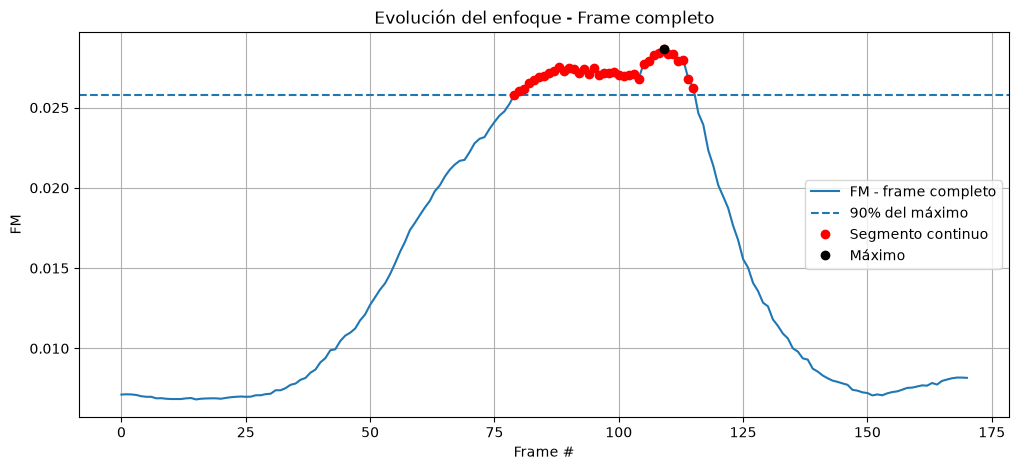

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    fm_frame_completo,
    label='FM - frame completo'
)

plt.axhline(
    umbral_90_completo,
    linestyle='--',
    label='90% del máximo'
)

plt.plot(
    frames_enfocados_completo,
    fm_frame_completo[frames_enfocados_completo],
    'ro',
    label='Segmento continuo'
)

plt.plot(
    frame_max_completo,
    fm_max_completo,
    'ko',
    label='Máximo'
)

plt.xlabel('Frame #')
plt.ylabel('FM')
plt.title('Evolución del enfoque - Frame completo')
plt.grid()
plt.legend()
plt.show()


### 5.2 Verificación visual

Comparo un frame anterior al segmento, el frame de máximo FM y un frame posterior. Esta inspección visual funciona como control de lo detectado por la métrica.


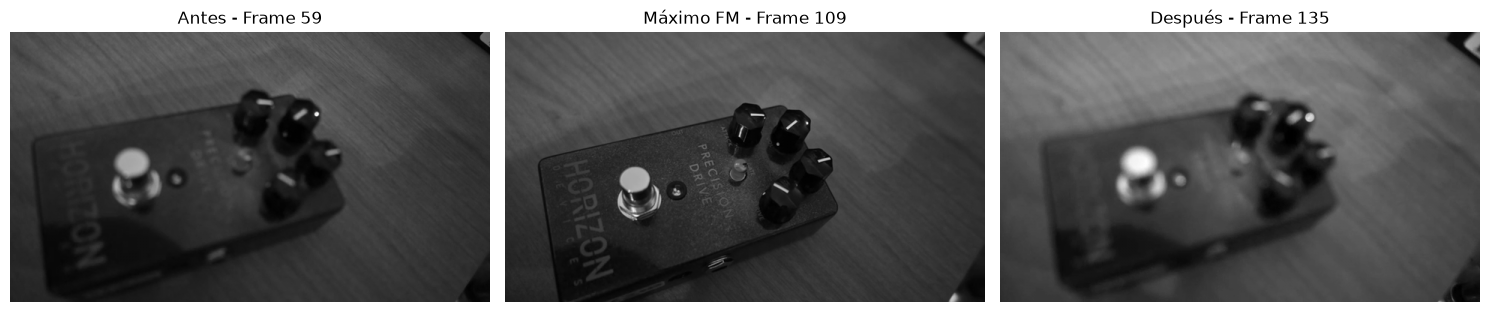

In [9]:
frame_antes = max(0, inicio_completo - 20)
frame_despues = min(len(frames_grises) - 1, fin_completo + 20)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(frames_grises[frame_antes], cmap='gray')
plt.title('Antes - Frame ' + str(frame_antes))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(frames_grises[frame_max_completo], cmap='gray')
plt.title('Máximo FM - Frame ' + str(frame_max_completo))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(frames_grises[frame_despues], cmap='gray')
plt.title('Después - Frame ' + str(frame_despues))
plt.axis('off')

plt.tight_layout()
plt.show()


## 6. Experimento 2: ROI central proporcional

Para la segunda medición se utilizo una ROI central de aproximadamente el **10% del área total** del frame.

Si se quiere conservar la proporción de la imagen, no se debe multiplicar ancho y alto por `0.10`, porque eso daría una región del 1% del área.

Por eso se aplica:

\[
escala = \sqrt{0.10}
\]

al ancho y al alto.


In [10]:
fraccion_area = 0.10
escala = np.sqrt(fraccion_area)

roi_width = int(frame_width * escala)
roi_height = int(frame_height * escala)

x_ini = (frame_width - roi_width) // 2
y_ini = (frame_height - roi_height) // 2
x_fin = x_ini + roi_width
y_fin = y_ini + roi_height

area_frame = frame_width * frame_height
area_roi = roi_width * roi_height
porcentaje_real_roi = 100 * area_roi / area_frame

print('Tamaño del frame:', frame_width, 'x', frame_height)
print('Tamaño de la ROI:', roi_width, 'x', roi_height)
print('Porcentaje real del área:', round(porcentaje_real_roi, 2), '%')


Tamaño del frame: 640 x 360
Tamaño de la ROI: 202 x 113
Porcentaje real del área: 9.91 %


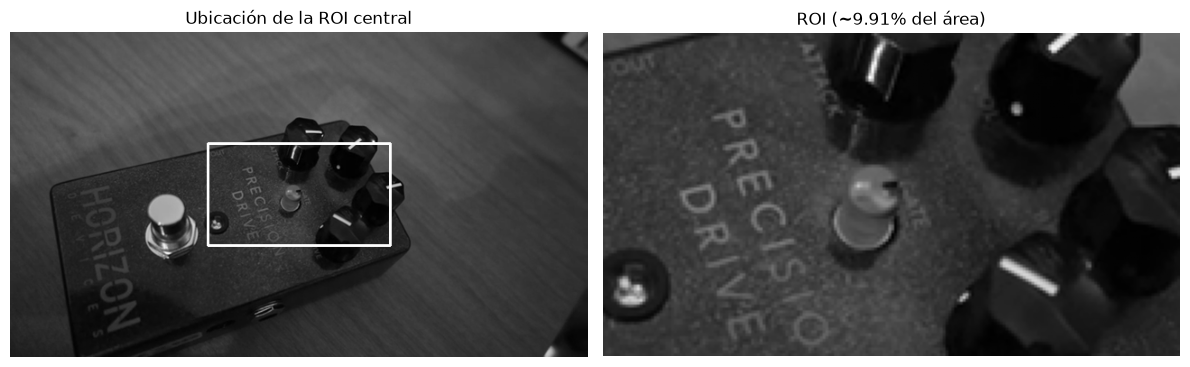

In [11]:
frame_ejemplo = frames_grises[frame_max_completo]
roi_ejemplo = frame_ejemplo[y_ini:y_fin, x_ini:x_fin]

# Para mostrar también la ubicación de la ROI en el frame
frame_roi_marcada = cv2.cvtColor(frame_ejemplo, cv2.COLOR_GRAY2RGB)
cv2.rectangle(
    frame_roi_marcada,
    (x_ini, y_ini),
    (x_fin, y_fin),
    (255, 255, 255),
    2
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(frame_roi_marcada)
plt.title('Ubicación de la ROI central')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(roi_ejemplo, cmap='gray')
plt.title('ROI (~' + str(round(porcentaje_real_roi, 2)) + '% del área)')
plt.axis('off')

plt.tight_layout()
plt.show()


### 6.1 FM sobre la ROI

Se repite la misma métrica, pero ahora únicamente sobre la región central.


In [12]:
fm_roi = []

for frame_gris in frames_grises:
    roi = frame_gris[y_ini:y_fin, x_ini:x_fin]
    fm_roi.append(medir_enfoque_fm(roi))

fm_roi = np.array(fm_roi)

resultado_roi = segmento_continuo_alrededor_maximo(
    fm_roi,
    proporcion=0.90
)

fm_max_roi = resultado_roi['fm_max']
frame_max_roi = resultado_roi['frame_max']
umbral_90_roi = resultado_roi['umbral']
inicio_roi = resultado_roi['inicio']
fin_roi = resultado_roi['fin']
frames_enfocados_roi = resultado_roi['indices']

print('FM máximo ROI:', fm_max_roi)
print('Frame de máximo FM en ROI:', frame_max_roi)
print('Umbral del 90%:', umbral_90_roi)
print('Segmento continuo de máximo enfoque ROI:',
      inicio_roi, 'a', fin_roi)
print('Cantidad de frames del segmento:',
      resultado_roi['cantidad'])


FM máximo ROI: 0.35770612459476037
Frame de máximo FM en ROI: 111
Umbral del 90%: 0.3219355121352843
Segmento continuo de máximo enfoque ROI: 103 a 113
Cantidad de frames del segmento: 11


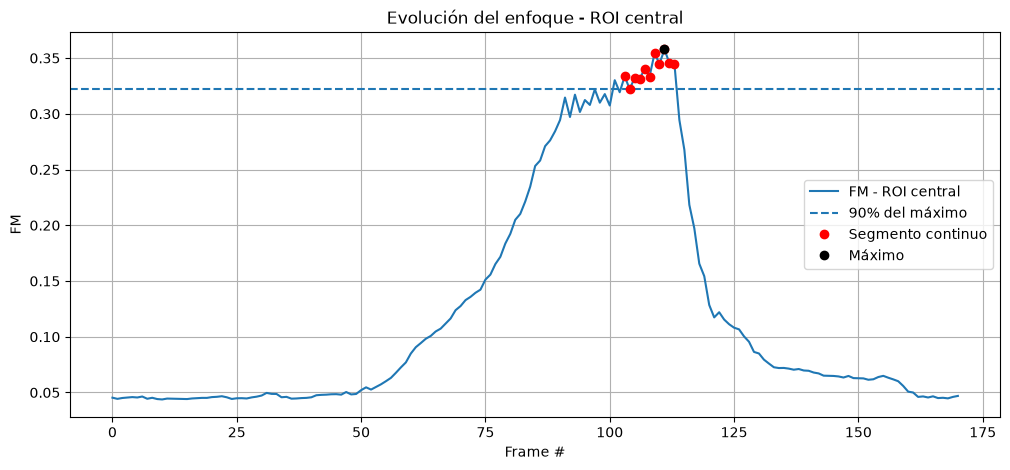

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    fm_roi,
    label='FM - ROI central'
)

plt.axhline(
    umbral_90_roi,
    linestyle='--',
    label='90% del máximo'
)

plt.plot(
    frames_enfocados_roi,
    fm_roi[frames_enfocados_roi],
    'ro',
    label='Segmento continuo'
)

plt.plot(
    frame_max_roi,
    fm_max_roi,
    'ko',
    label='Máximo'
)

plt.xlabel('Frame #')
plt.ylabel('FM')
plt.title('Evolución del enfoque - ROI central')
plt.grid()
plt.legend()
plt.show()


## 7. Comparación: frame completo vs. ROI

Los valores absolutos de FM no se comparan directamente porque las dos mediciones se realizan sobre regiones de distinto tamaño y contenido.

La comparación se centra en:

- la forma de las curvas;
- el frame donde aparece el máximo;
- y la extensión del segmento continuo de máximo enfoque.


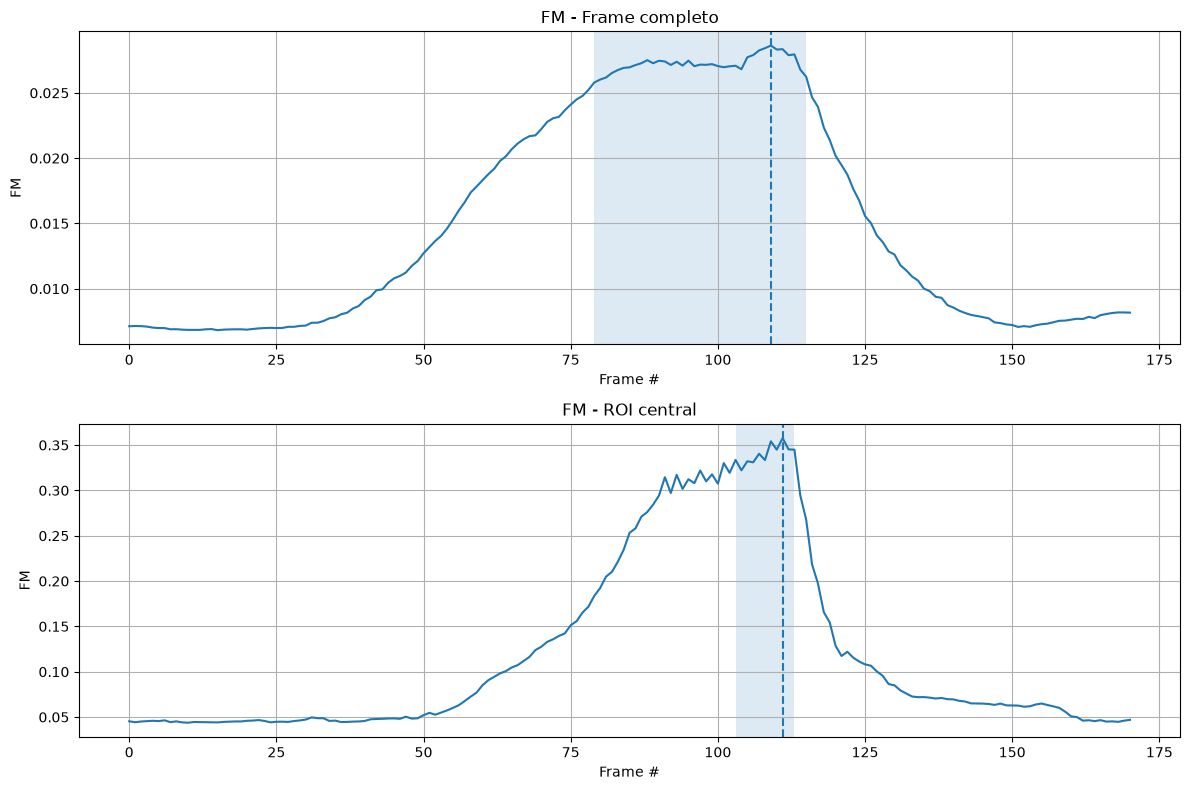

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(fm_frame_completo)
plt.axvline(frame_max_completo, linestyle='--')
plt.axvspan(inicio_completo, fin_completo, alpha=0.15)
plt.title('FM - Frame completo')
plt.xlabel('Frame #')
plt.ylabel('FM')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(fm_roi)
plt.axvline(frame_max_roi, linestyle='--')
plt.axvspan(inicio_roi, fin_roi, alpha=0.15)
plt.title('FM - ROI central')
plt.xlabel('Frame #')
plt.ylabel('FM')
plt.grid()

plt.tight_layout()
plt.show()


## 8. Resultados obtenidos

Esta celda imprime los resultados directamente desde las variables calculadas. No hay valores escritos manualmente.


In [15]:
tiempo_max_completo = frame_max_completo / fps if fps > 0 else np.nan
tiempo_max_roi = frame_max_roi / fps if fps > 0 else np.nan

print('RESULTADOS - FRAME COMPLETO')
print('FM máximo:', round(fm_max_completo, 6))
print('Frame de máximo FM:', frame_max_completo)
print('Tiempo aproximado del máximo:', round(tiempo_max_completo, 2), 's')
print('Segmento continuo al 90%:',
      inicio_completo, 'a', fin_completo)
print('Cantidad de frames del segmento:',
      resultado_completo['cantidad'])

print('\nRESULTADOS - ROI CENTRAL')
print('Tamaño ROI:', roi_width, 'x', roi_height)
print('Área real de la ROI:', round(porcentaje_real_roi, 2), '%')
print('FM máximo ROI:', round(fm_max_roi, 6))
print('Frame de máximo FM ROI:', frame_max_roi)
print('Tiempo aproximado del máximo:', round(tiempo_max_roi, 2), 's')
print('Segmento continuo al 90%:',
      inicio_roi, 'a', fin_roi)
print('Cantidad de frames del segmento:',
      resultado_roi['cantidad'])

print('\nDIFERENCIA ENTRE LOS MÁXIMOS')
print('Diferencia de frames:',
      abs(frame_max_completo - frame_max_roi))


RESULTADOS - FRAME COMPLETO
FM máximo: 0.028624
Frame de máximo FM: 109
Tiempo aproximado del máximo: 3.64 s
Segmento continuo al 90%: 79 a 115
Cantidad de frames del segmento: 37

RESULTADOS - ROI CENTRAL
Tamaño ROI: 202 x 113
Área real de la ROI: 9.91 %
FM máximo ROI: 0.357706
Frame de máximo FM ROI: 111
Tiempo aproximado del máximo: 3.7 s
Segmento continuo al 90%: 103 a 113
Cantidad de frames del segmento: 11

DIFERENCIA ENTRE LOS MÁXIMOS
Diferencia de frames: 2


# 9. Punto extra: Unsharp Masking

Se plica Unsharp Masking únicamente cerca de los extremos del segmento de máximo enfoque.

La implementación mantiene el procedimiento trabajado en clase:

1. `GaussianBlur`;
2. combinación de imagen original y suavizada mediante `cv2.addWeighted`.

No se intenta corregir frames muy desenfocados. La prueba busca observar si se pueden reforzar detalles en frames próximos a la zona de buen enfoque.


In [16]:
def unsharp_masking(imagen_gris, k=1):
    gauss = cv2.GaussianBlur(imagen_gris, (7, 7), 0.5)

    imagen_sharp = cv2.addWeighted(
        imagen_gris,
        k + 1,
        gauss,
        -k,
        0
    )

    return imagen_sharp


In [17]:
margen = 15
k = 1

fm_con_unsharp = []
frames_procesados_grises = []

for i, frame_gris in enumerate(frames_grises):

    aplicar_antes = (
        inicio_completo - margen <= i < inicio_completo
    )

    aplicar_despues = (
        fin_completo < i <= fin_completo + margen
    )

    if aplicar_antes or aplicar_despues:
        frame_procesado = unsharp_masking(frame_gris, k=k)
    else:
        frame_procesado = frame_gris.copy()

    frames_procesados_grises.append(frame_procesado)
    fm_con_unsharp.append(medir_enfoque_fm(frame_procesado))

fm_con_unsharp = np.array(fm_con_unsharp)

# Para comparar en las mismas condiciones se conserva
# el umbral del 90% obtenido sobre el video original.
resultado_unsharp = segmento_continuo_alrededor_maximo(
    fm_con_unsharp,
    umbral_fijo=umbral_90_completo
)

inicio_extra = resultado_unsharp['inicio']
fin_extra = resultado_unsharp['fin']

print('Segmento original:',
      inicio_completo, 'a', fin_completo)

print('Segmento con Unsharp:',
      inicio_extra, 'a', fin_extra)

print('Cantidad de frames original:',
      resultado_completo['cantidad'])

print('Cantidad de frames con Unsharp:',
      resultado_unsharp['cantidad'])


Segmento original: 79 a 115
Segmento con Unsharp: 76 a 116
Cantidad de frames original: 37
Cantidad de frames con Unsharp: 41


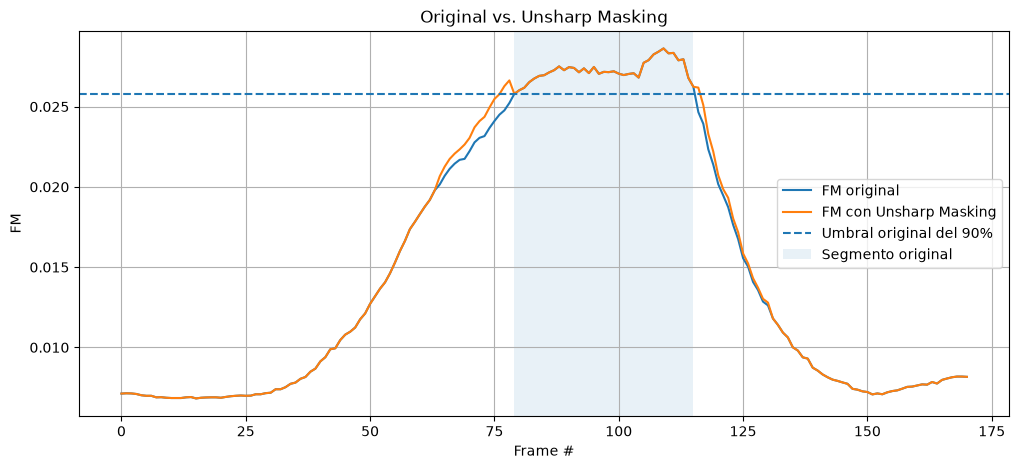

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    fm_frame_completo,
    label='FM original'
)

plt.plot(
    fm_con_unsharp,
    label='FM con Unsharp Masking'
)

plt.axhline(
    umbral_90_completo,
    linestyle='--',
    label='Umbral original del 90%'
)

plt.axvspan(
    inicio_completo,
    fin_completo,
    alpha=0.10,
    label='Segmento original'
)

plt.xlabel('Frame #')
plt.ylabel('FM')
plt.title('Original vs. Unsharp Masking')
plt.grid()
plt.legend()
plt.show()


### 9.1 Comparación visual: original vs. procesado

Para observar el efecto del filtro elijo un frame cercano al inicio del segmento, dentro de la zona donde se aplica Unsharp.


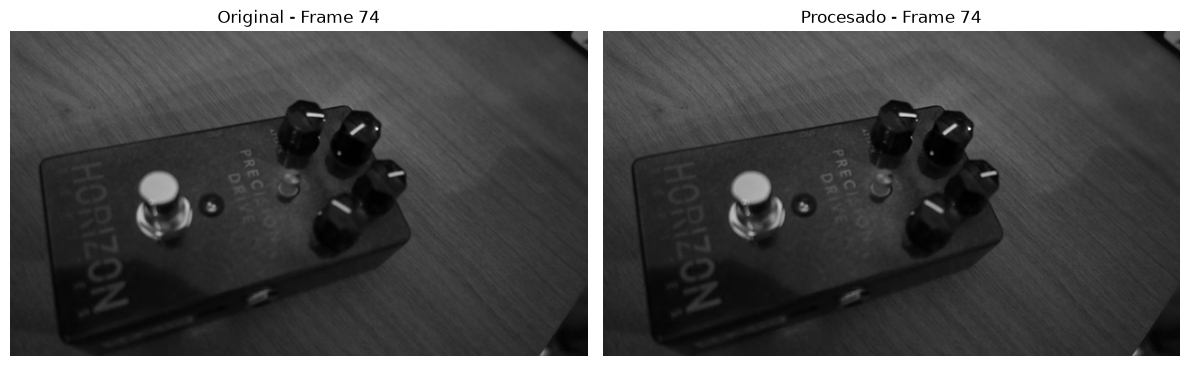

FM original: 0.023668
FM procesado: 0.024944


In [19]:
frame_comparacion = max(
    0,
    min(
        len(frames_grises) - 1,
        inicio_completo - min(5, margen)
    )
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(frames_grises[frame_comparacion], cmap='gray')
plt.title('Original - Frame ' + str(frame_comparacion))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(frames_procesados_grises[frame_comparacion], cmap='gray')
plt.title('Procesado - Frame ' + str(frame_comparacion))
plt.axis('off')

plt.tight_layout()
plt.show()

print('FM original:',
      round(fm_frame_completo[frame_comparacion], 6))
print('FM procesado:',
      round(fm_con_unsharp[frame_comparacion], 6))


## 10. Video comparativo original vs. procesado

Se genera un video lado a lado para revisar visualmente el efecto del procesamiento a lo largo de toda la secuencia.


In [20]:
output_video_path = 'comparacion_original_vs_unsharp.mp4'

captura_video_original = cv2.VideoCapture(video_path)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_width = frame_width * 2
output_height = frame_height

out = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (output_width, output_height)
)

frame_count = 0

while True:
    ret, frame_color = captura_video_original.read()

    if not ret:
        break

    frame_procesado_bgr = cv2.cvtColor(
        frames_procesados_grises[frame_count],
        cv2.COLOR_GRAY2BGR
    )

    comparacion = np.hstack(
        (frame_color, frame_procesado_bgr)
    )

    out.write(comparacion)
    frame_count += 1

captura_video_original.release()
out.release()

print('Video comparativo guardado en:', output_video_path)


Video comparativo guardado en: comparacion_original_vs_unsharp.mp4


## 11. Conclusiones basadas en la ejecución

Las conclusiones se construyen a partir de los resultados calculados en las celdas anteriores.


In [21]:
diferencia_maximos = abs(
    frame_max_completo - frame_max_roi
)

cambio_segmento = (
    resultado_unsharp['cantidad']
    - resultado_completo['cantidad']
)

print('CONCLUSIONES')

print(
    '1. La métrica FM encontró su máximo en el frame',
    frame_max_completo,
    'para el frame completo y en el frame',
    frame_max_roi,
    'para la ROI.'
)

print(
    '2. La diferencia entre ambos máximos fue de',
    diferencia_maximos,
    'frames.'
)

if resultado_roi['cantidad'] < resultado_completo['cantidad']:
    print(
        '3. En esta ejecución, la ROI produjo un segmento '
        'continuo de máximo enfoque más acotado que el frame completo:',
        resultado_roi['cantidad'],
        'frames frente a',
        resultado_completo['cantidad'],
        'frames.'
    )
elif resultado_roi['cantidad'] > resultado_completo['cantidad']:
    print(
        '3. En esta ejecución, la ROI produjo un segmento '
        'continuo de máximo enfoque más amplio que el frame completo:',
        resultado_roi['cantidad'],
        'frames frente a',
        resultado_completo['cantidad'],
        'frames.'
    )
else:
    print(
        '3. En esta ejecución, la ROI y el frame completo '
        'produjeron segmentos de igual longitud.'
    )

print(
    '4. El criterio del 90% se aplicó buscando el segmento '
    'continuo que contiene al máximo, evitando unir grupos separados '
    'de frames que superen el umbral.'
)

if cambio_segmento > 0:
    print(
        '5. Con Unsharp Masking, y manteniendo el mismo umbral '
        'del video original, el segmento continuo aumentó en',
        cambio_segmento,
        'frames.'
    )
elif cambio_segmento < 0:
    print(
        '5. Con Unsharp Masking, y manteniendo el mismo umbral '
        'del video original, el segmento continuo disminuyó en',
        abs(cambio_segmento),
        'frames.'
    )
else:
    print(
        '5. Con Unsharp Masking, y manteniendo el mismo umbral '
        'del video original, la longitud del segmento continuo no cambió.'
    )

print(
    '6. La comparación visual original/procesado permite revisar '
    'si el aumento de FM corresponde también a una mejora observable '
    'en los frames cercanos a la región enfocada.'
)


CONCLUSIONES
1. La métrica FM encontró su máximo en el frame 109 para el frame completo y en el frame 111 para la ROI.
2. La diferencia entre ambos máximos fue de 2 frames.
3. En esta ejecución, la ROI produjo un segmento continuo de máximo enfoque más acotado que el frame completo: 11 frames frente a 37 frames.
4. El criterio del 90% se aplicó buscando el segmento continuo que contiene al máximo, evitando unir grupos separados de frames que superen el umbral.
5. Con Unsharp Masking, y manteniendo el mismo umbral del video original, el segmento continuo aumentó en 4 frames.
6. La comparación visual original/procesado permite revisar si el aumento de FM corresponde también a una mejora observable en los frames cercanos a la región enfocada.


---

## Resumen

En el notebook:

- implementación la métrica FM del paper;
- Prueba inicial sobre un frame;
- analisis el video completo;
- definicion el máximo y el **segmento continuo** que permanece por encima del 90%;
- calcular una ROI central proporcional al 10% del área;
- comparar frame completo y ROI mediante gráficos y verificación visual;
- aplicar Unsharp Masking con `GaussianBlur` + `addWeighted`;
- comparar original y procesado tanto en imágenes como en un video lado a lado;
- y dejar resultados y conclusiones vinculados directamente con las variables obtenidas al ejecutar el notebook.
